In [ ]:
%pip install wordcloud
%pip install plotly
%pip install scikit-learn
%pip install network

  Preparing metadata (setup.py) ... done
  Created wheel for network: filename=network-0.1-py3-none-any.whl size=3138 sha256=9811bbf9d7506921a7d2ca520283d02053b5b551672a3feec4c8ce21e5eb7667
  Stored in directory: /root/.cache/pip/wheels/e7/5a/7a/7f15bea66afb5505b9d10cc7bd8964cb77f0ce736df5b104c8
Successfully built network


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt


from google.colab import files
from collections import Counter

# **Cargar los Datos**

In [ ]:
# Then run your code
uploaded = files.upload()
filename = list(uploaded.keys())[0]

try:
    df = pd.read_csv(filename)
except:
    df = pd.read_csv(filename)

print(f"\n✅ Datos cargados: {df.shape[0]} filas, {df.shape[1]} columnas")
df = df.drop(columns=['Marca temporal'])
df.head()

Saving Encuesta Preferencia de Entidades Financieras (Respuestas) - Respuestas de formulario 1.csv to Encuesta Preferencia de Entidades Financieras (Respuestas) - Respuestas de formulario 1 (1).csv

✅ Datos cargados: 304 filas, 21 columnas


,¿Cuál es tu rango de edad?,¿Cuál es tu rango de ingreso mensual?,¿Cuántas aplicaciones bancarias o financieras utilizas activamente?,¿Conoces qué es una fintech?,¿Qué tipo de instituciones financiera utilizas con mayor frecuencia?,¿Cuáles Fintechs utilizas? (Selección múltiple),"Si utilizas fintechs, ¿qué te preocupa de usarlas? (Selección múltiple)",¿Dirías que prefieres Fintechs sobre Bancos tradicionales?,"Si la anterior pregunta fue que tienes usos diferentes para Fintechs y Bancos Tradicionales responde que usos si no, escribe NA.","Si has utilizado tanto Fintechs como bancos tradicionales, ¿qué factor influyó MÁS en tu preferencia?","¿Qué tan difícil te resulta completar una transacción típica (transferencia, pago de servicio) en tu app bancaria principal?","Pensando en la última vez que usaste tu app bancaria, ¿qué fue lo que más te FRUSTRÓ? (Selección múltiple)",Y ¿qué fue lo que más te GUSTÓ? (Selección múltiple),"Cuando tienes un problema con tu banco, ¿qué tipo de atención prefieres?",¿Qué tanto confías en tu institución financiera principal para manejar tu dinero y datos personales?,"¿Has tenido alguna vez una preocupación de seguridad con una institución financiera? Si fue así, ¿qué la causó? (Selección múltiple)",¿Cuál es tu banco principal?,¿Qué te haría cambiar de banco? (Selección múltiple),"¿Qué tipo de beneficios valoras más de tu banco? (Selección múltiple, máximo 3)",¿Qué tan importante es para ti tener acceso fácil a sucursales físicas?
0,18-25,"Menos de $10,000 MXN",2,He escuchado el término pero no estoy seguro,Banca tradicional,Nu (Nu Bank),"Seguridad de mi dinero, Riesgo tecnológico (ca...",Si,NaN,Rápidez,1,"Errores o caídas, Login o autenticación","Velocidad, Diseño y facilidad de uso, Funcione...",Depende del tipo de problema,3,No he tenido ningún problema,BBVA,"Comisiones más bajas, Mejor app, Mejor atenció...",Tasas de rendimiento,5
1,18-25,"Menos de $10,000 MXN",2,He escuchado el término pero no estoy seguro,Banca tradicional,Klar,"Falta de sucursales físicas, Soporte limitado,...",Tengo usos diferentes para Fintechs y Bancos T...,Los bancos tradicionales los suelo emplear en ...,Comisiones bajas,1,Soporte difícil de contactar,Diseño y facilidad de uso,Atención humana,4,Fraude o cargo no autorizado,BBVA,"Comisiones más bajas, Mejor app, Mejores tasas...",Ninguno,4
2,18-25,"Menos de $10,000 MXN",2,Si,Banca tradicional,Mercado pago,"Regulación o respaldo institucional (IPAB), Ri...",No,NaN,Recompensas,1,"Tiempos de carga, Errores o caídas",Nada en particular,Depende del tipo de problema,3,No he tenido ningún problema,BBVA,"Recompensas más atractivas, Recomendación cerc...","Acceso anticipado a productos, Descuentos en c...",4
3,18-25,"Menos de $10,000 MXN",2,He escuchado el término pero no estoy seguro,Banca tradicional,Mercado pago,"Seguridad de mi dinero, Falta de sucursales fí...",No,NaN,Rápidez,5,"Tiempos de carga, Procesos con muchos pasos, D...","Seguridad (biometría, alertas)",Depende del tipo de problema,5,No he tenido ningún problema,BBVA,Mala experiencia con mi banco actual,"Cashback, Sin comisiones, Tasas de rendimiento",5
4,18-25,"Menos de $10,000 MXN",2,Si,Ambos,"Mercado pago, Didi pay","Regulación o respaldo institucional (IPAB), Ri...",Tengo usos diferentes para Fintechs y Bancos T...,Ventajas en aplicaciones de consumo como Didi ...,Confianza institucional,3,"Tiempos de carga, Errores o caídas, Difícil en...","Seguridad (biometría, alertas)",Atención humana,3,Fraude o cargo no autorizado,Banamex,"Mejor app, Mejor atención, Mejores tasas","Acceso anticipado a productos, Sin comisiones",4


# Funciones auxiliares de limpieza


In [ ]:
# ── Patrón de NA inválidos ────────────────────────────────────
NA_PATTERNS = re.compile(
    r'^\s*(na\.?|n\.?a\.?|nan|n\s+a|ma|ña|xx?|x|-|\.)\s*$',
    re.IGNORECASE
)

def es_na_invalido(valor):
    if pd.isna(valor):
        return True
    s = str(valor).strip()
    return bool(NA_PATTERNS.match(s)) or s == ''

def es_junk(valor):
    """Identifica si un valor es basura/irrelevante"""
    if pd.isna(valor):
        return True
    s = str(valor).strip().lower()
    junk_patterns = [
        'ninguna', 'ninguno', 'n/a', 'na', 'n.a.', 'nulo', 'null',
        'sin respuesta', 'no aplica', 'ningun', 'ninguna fintech',
        'no utilizo', 'no uso', 'ningun banco', 'no tengo'
    ]
    return s in junk_patterns or len(s) == 0

def limpiar_multiple(valor):
    """Limpia campos de selección múltiple (separados por comas)"""
    if es_na_invalido(valor):
        return []
    items = [item.strip() for item in str(valor).split(',')]
    return [item for item in items if not es_na_invalido(item)]

def limpiar_texto_libre(valor):
    """Limpia campos de texto libre (reemplaza NA inválidos con NaN)"""
    if es_na_invalido(valor):
        return np.nan
    texto = str(valor).strip()
    if texto.upper() in ['NA', 'N/A', 'N.A.', 'NAN', 'NINGUNO', 'NULL']:
        return np.nan
    return texto

# Diccionarios de unificación

In [ ]:
# ── Diccionario de unificación bancaria ───────────────────────
UNIFICACION_BANCO = {
    'bbva': 'BBVA',
    'banamex': 'Banamex', 'citibanamex': 'Banamex',
    'banorte': 'Banorte',
    'santander': 'Santander',
    'hsbc': 'HSBC',
    'scotiabank': 'Scotiabank',
    'inbursa': 'Inbursa',
    'banco azteca': 'Banco Azteca',
    'bancoppel': 'BanCoppel',
    'banjercito': 'Banjercito',
    'invex': 'INVEX',
    'american express': 'American Express',
    'american expres': 'American Express',
    'bw bank': 'BW Bank',
    'actinver': 'Actinver',
    'td canada trust': 'TD Canada Trust',
    'banregio': 'Banregio',
    'revolut': 'Revolut',
    'no uso bancos': 'No usa bancos',
}

def unificar_nombre_banco(nombre):
    clave = nombre.strip().lower().rstrip()
    return UNIFICACION_BANCO.get(clave, nombre.strip())

def limpiar_banco(valor):
    """Limpia y unifica nombres de bancos"""
    if es_na_invalido(valor):
        return np.nan
    nombre = str(valor).strip()
    return unificar_nombre_banco(nombre)

# ── Diccionario de unificación de Fintechs ────────────────────
UNIFICACION_FINTECH = {
    'nu (nu bank)': 'Nu', 'nu bank': 'Nu', 'nu': 'Nu',
    'mercado pago': 'Mercado Pago', 'mercadopago': 'Mercado Pago',
    'mercado libre': 'Mercado Pago',
    'klar': 'Klar',
    'spin by oxxo': 'Spin by Oxxo',
    'rappi card': 'Rappi Card', 'rappi': 'Rappi Card',
    'hey banco': 'Hey Banco',
    'stori': 'Stori',
    'albo': 'Albo',
    'gbm': 'GBM',
    'plata': 'Plata', 'plata card': 'Plata',
    'binance': 'Binance',
    'didi pay': 'Didi Pay', 'didi card': 'Didi Pay', 'didi': 'Didi Pay',
    'kueski pay': 'Kueski Pay',
    'clip': 'Clip',
    'konfio': 'Konfio',
    'paypal': 'PayPal',
    'wise': 'Wise',
    'broxel': 'Broxel',
    'bitso': 'Bitso',
    'finsus': 'Finsus',
    'clupp': 'Clupp',
    'kubo': 'Kubo',
    'open bank': 'Open Bank',
    'vexi': 'Vexi',
    'profuturo': 'Profuturo',
    'bankaool': 'Bankaool',
    'revolut': 'Revolut',
    'binance y revolut': ['Binance', 'Revolut'],
    'konfio y clip': ['Konfio', 'Clip'],
    'bbva': None, 'santander': None, 'inbursa': None,
}

# Fintechs que podrían aparecer en Banco_Principal por error
FINTECHS_EN_BANCO = {
    'nu', 'mercado pago', 'klar', 'stori', 'albo', 'hey banco',
    'rappi card', 'spin by oxxo', 'plata', 'gbm', 'revolut',
    'binance', 'didi pay', 'kueski pay', 'clip', 'konfio',
    'paypal', 'wise', 'broxel', 'bitso', 'vexi',
}

UNIFICACION_GUSTO = {
    'seguridad (biometría' : 'Seguridad (biometría, alertas)',  # mitad izquierda del split
'alertas)' : 'Seguridad (biometría, alertas)',  # mitad derecha del split
'seguridad (biometría, alertas)' : 'Seguridad (biometría, alertas)'  # entrada completa
}

def limpiar_gusto(valor):
    """Limpia col. Gusto usando split por ';' primero, luego normaliza
    con UNIFICACION_GUSTO para reagrupar fragmentos rotos por coma."""
    if es_na_invalido(valor):
        return []
    s = str(valor).strip()
    # Preferir split por ';' si el string lo usa
    if ';' in s:
        items = [x.strip() for x in s.split(';')]
    else:
        items = [x.strip() for x in s.split(',')]

    resultado = []
    seen = set()
    for item in items:
        if es_na_invalido(item):
            continue
        canon = UNIFICACION_GUSTO.get(item.lower(), item)
        if canon and canon not in seen:
            seen.add(canon)
            resultado.append(canon)
    return resultado

def limpiar_fintechs(valor):
    """Limpia y unifica nombres de fintechs"""
    if es_na_invalido(valor):
        return []

    items_raw = [item.strip().lower() for item in str(valor).split(',')]
    resultado = []

    for item in items_raw:
        if es_na_invalido(item) or es_junk(item):
            continue
        canon = UNIFICACION_FINTECH.get(item, item.title())
        if canon is None:
            continue
        if isinstance(canon, list):
            resultado.extend(canon)
        else:
            resultado.append(canon)

    seen = set()
    resultado_limpio = []
    for item in resultado:
        if item not in seen:
            seen.add(item)
            resultado_limpio.append(item)

    return resultado_limpio

def mover_fintechs_de_banco(row):
    """Mueve fintechs que aparecen en Banco_Principal a Fintechs_Utilizadas"""
    banco = row.get('Banco_Principal', np.nan)
    fintechs = row.get('Fintechs_Utilizadas', [])

    if pd.isna(banco):
        return banco, fintechs

    banco_str = str(banco).strip().lower()

    if banco_str in FINTECHS_EN_BANCO:
        if isinstance(fintechs, list):
            fintechs.append(banco_str.title())
        else:
            fintechs = [banco_str.title()]
        return np.nan, fintechs

    return banco, fintechs

# Cambiamos nombres de columnas



In [ ]:
# ── Normalizar nombres de columnas (solo acentos y espacios) ─
df.columns = (
    df.columns
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('¿', '').str.replace('?', '')
    .str.replace('á','a').str.replace('é','e')
    .str.replace('í','i').str.replace('ó','o').str.replace('ú','u')
)

# ── Renombrar a nombres cortos ───────────────────────────────
rename_map = {
    'Cual_es_tu_rango_de_edad':
        'Rango_Edad',
    'Cual_es_tu_rango_de_ingreso_mensual':
        'Rango_Ingreso',
    'Cuantas_aplicaciones_bancarias_o_financieras_utilizas_activamente':
        '#_Apps_Tiene',
    'Conoces_que_es_una_fintech':
        'Conoce_Fintech',
    'Que_tipo_de_instituciones_financiera_utilizas_con_mayor_frecuencia':
        'Tipo_Institucion',
    'Cuales_Fintechs_utilizas_(Seleccion_multiple)':
        'Fintechs_Utilizadas',
    'Si_utilizas_fintechs,_que_te_preocupa_de_usarlas_(Seleccion_multiple)':
        'Preocupacion_Fintechs',
    'Dirias_que_prefieres_Fintechs_sobre_Bancos_tradicionales':
        'Preferencia_Fintech_vs_Tradicional',
    'Si_la_anterior_pregunta_fue_que_tienes_usos_diferentes_para_Fintechs_y_Bancos_Tradicionales_responde_que_usos_si_no,_escribe_NA.':
        'Usos_Diferentes',
    'Si_has_utilizado_tanto_Fintechs_como_bancos_tradicionales,_que_factor_influyo_MÁS_en_tu_preferencia':
        'Factor_Preferencia',
    'Que_tan_dificil_te_resulta_completar_una_transaccion_tipica_(transferencia,_pago_de_servicio)_en_tu_app_bancaria_principal':
        'Dificultad_Transaccion',
    'Pensando_en_la_ultima_vez_que_usaste_tu_app_bancaria,_que_fue_lo_que_mas_te_FRUSTRÓ_(Seleccion_multiple)':
        'Frustracion',
    'Y_que_fue_lo_que_mas_te_GUSTÓ_(Seleccion_multiple)':
        'Gusto',
    'Cuando_tienes_un_problema_con_tu_banco,_que_tipo_de_atencion_prefieres':
        'Preferencia_Atencion',
    'Que_tanto_confias_en_tu_institucion_financiera_principal_para_manejar_tu_dinero_y_datos_personales':
        'Confianza_Institucion',
    'Has_tenido_alguna_vez_una_preocupacion_de_seguridad_con_una_institucion_financiera_Si_fue_asi,_que_la_causo_(Seleccion_multiple)':
        'Preocupacion_Seguridad',
    'Cual_es_tu_banco_principal':
        'Banco_Principal',
    'Que_te_haria_cambiar_de_banco_(Seleccion_multiple)':
        'Razon_Consideraria_Cambiar',
    'Que_tipo_de_beneficios_valoras_mas_de_tu_banco_(Seleccion_multiple,_maximo_3)':
        'Beneficios_Valorados',
    'Que_tan_importante_es_para_ti_tener_acceso_facil_a_sucursales_fisicas':
        'Importancia_Acceso_Sucursales',
}
df = df.rename(columns=rename_map)

In [ ]:
#Columnas de opción múltiple genéricas
for col in ['Preocupacion_Fintechs', 'Frustracion',
            'Preocupacion_Seguridad', 'Razon_Consideraria_Cambiar',
            'Beneficios_Valorados']:
            df[col] = df[col].apply(limpiar_multiple)

if 'Gusto' in df.columns:
    df['Gusto'] = df['Gusto'].apply(limpiar_gusto)

#Fintechs_Utilizadas — limpieza con unificación
if 'Fintechs_Utilizadas' in df.columns:
    df['Fintechs_Utilizadas'] = df['Fintechs_Utilizadas'].apply(limpiar_fintechs)

# ── CORRECCIÓN BUG 1: Banco_Principal ahora se limpia como lista múltiple ──
# Antes: limpiar_banco() trataba "banjercito, invex" como UN solo banco.
# Ahora: limpiar_bancos_lista() separa por coma y unifica cada banco.
def limpiar_bancos_lista(valor):
    """Limpia y unifica bancos; soporta múltiples separados por coma.
    Retorna una lista (puede tener 1 o más bancos)."""
    if es_na_invalido(valor):
        return []
    items = [item.strip() for item in str(valor).split(',')]
    resultado = []
    for item in items:
        if es_na_invalido(item):
            continue
        resultado.append(unificar_nombre_banco(item))
    # Deduplicar preservando orden
    seen = set()
    return [x for x in resultado if not (x in seen or seen.add(x))]

if 'Banco_Principal' in df.columns:
    df['Banco_Principal'] = df['Banco_Principal'].apply(limpiar_bancos_lista)

# Migrar fintechs que estaban en Banco_Principal
# mover_fintechs_de_banco ahora opera sobre listas
def mover_fintechs_de_banco(row):
    """Mueve fintechs que aparecen en Banco_Principal a Fintechs_Utilizadas"""
    bancos = row.get('Banco_Principal', [])
    fintechs = row.get('Fintechs_Utilizadas', [])
    if not isinstance(bancos, list):
        bancos = []
    if not isinstance(fintechs, list):
        fintechs = []

    bancos_limpios = []
    for banco in bancos:
        banco_str = str(banco).strip().lower()
        if banco_str in FINTECHS_EN_BANCO:
            nombre_title = banco_str.title()
            if nombre_title not in fintechs:
                fintechs.append(nombre_title)
        else:
            bancos_limpios.append(banco)

    return bancos_limpios, fintechs

resultados = df.apply(mover_fintechs_de_banco, axis=1)
df['Banco_Principal'] = resultados.apply(lambda x: x[0])
df['Fintechs_Utilizadas'] = resultados.apply(lambda x: x[1])

#Texto libre
for col in ['Usos_Diferentes', 'Factor_Preferencia']:
    if col in df.columns:
        df[col] = df[col].apply(limpiar_texto_libre)

#Categóricas simples
for col in ['Rango_Edad', 'Conoce_Fintech',
            'Preferencia_Fintech_vs_Tradicional', 'Preferencia_Atencion']:
    if col in df.columns:
        df[col] = df[col].apply(
            lambda v: np.nan if es_na_invalido(v) else str(v).strip()
        )

# #_Apps_Tiene: texto → entero
def apps_a_numero(v):
    if es_na_invalido(v): return np.nan
    s = str(v).strip()
    if re.match(r'4\s*o\s*m', s, re.IGNORECASE): return 4
    try: return int(s)
    except ValueError: return np.nan

if '#_Apps_Tiene' in df.columns:
    df['#_Apps_Tiene'] = df['#_Apps_Tiene'].apply(apps_a_numero)

#Rango_Ingreso: normalizar a rango limpio
MAPA_INGRESO = {
    'Menos de $10,000 MXN': '< $10,000',
    '$10,000MXN–$20,000MXN': '$10,000–$20,000',
    '$20,000MXN–$50,000MXN': '$20,000–$50,000',
    'Más de $50,000MXN': '> $50,000',
    'Prefiero no decir': np.nan,
}
if 'Rango_Ingreso' in df.columns:
    df['Rango_Ingreso'] = df['Rango_Ingreso'].apply(
        lambda v: np.nan if es_na_invalido(v)
        else MAPA_INGRESO.get(str(v).strip(), str(v).strip())
    )

#Escalas numéricas Likert 1-5
for col in ['Dificultad_Transaccion', 'Confianza_Institucion', 'Importancia_Acceso_Sucursales']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

#Tipo_Usuario
if 'Tipo_Institucion' in df.columns:
    def clasificar_usuario(v):
        if pd.isna(v): return np.nan
        v = str(v).strip().lower()
        if v == 'banca tradicional': return 'Solo Tradicional'
        if v == 'fintechs': return 'Solo Fintech'
        if v == 'ambos': return 'Híbrido'
        return str(v).strip()
    df['Tipo_Usuario'] = df['Tipo_Institucion'].apply(clasificar_usuario)
    df = df.drop(columns=['Tipo_Institucion'])


In [ ]:
# ── Columna auxiliar Bancos_Lista (ya no hace falta, Banco_Principal ya ES lista) ──
# Banco_Principal ahora almacena listas directamente, igual que Fintechs_Utilizadas.
# Mantenemos el alias para no romper celdas posteriores.
df['Bancos_Lista'] = df['Banco_Principal']

#Categorizar confianza
if 'Confianza_Institucion' in df.columns:
    def categorizar_confianza(valor):
        if pd.isna(valor): return np.nan
        if valor <= 2: return 'Baja confianza'
        elif valor <= 4: return 'Confianza media'
        else: return 'Alta confianza'
    df['Confianza_Nivel'] = df['Confianza_Institucion'].apply(categorizar_confianza)
    print("\n * Confianza categorizada: 'Baja confianza', 'Confianza media', 'Alta confianza'")

#Categorizar dificultad
if 'Dificultad_Transaccion' in df.columns:
    def categorizar_dificultad(valor):
        if pd.isna(valor): return np.nan
        if valor <= 2: return 'Fácil'
        elif valor <= 4: return 'Moderado'
        else: return 'Difícil'
    df['Dificultad_Nivel'] = df['Dificultad_Transaccion'].apply(categorizar_dificultad)
    print("\n * Dificultad categorizada: 'Fácil', 'Moderado', 'Difícil'")

#Validar rangos Likert (1-5)
print("\n * Validación de rangos Likert:")
for col in ['Dificultad_Transaccion', 'Confianza_Institucion', 'Importancia_Acceso_Sucursales']:
    if col in df.columns:
        invalid = df[~df[col].between(1, 5) & df[col].notna()].shape[0]
        if invalid > 0:
            print(f" {col}: {invalid} valores fuera de rango (1-5) → reemplazados con NaN")
            df.loc[~df[col].between(1, 5), col] = np.nan
        else:
            print(f"  {col}: todos los valores en rango (1-5)")



 * Confianza categorizada: 'Baja confianza', 'Confianza media', 'Alta confianza'

 * Dificultad categorizada: 'Fácil', 'Moderado', 'Difícil'

 * Validación de rangos Likert:
  Dificultad_Transaccion: todos los valores en rango (1-5)
  Confianza_Institucion: todos los valores en rango (1-5)
  Importancia_Acceso_Sucursales: todos los valores en rango (1-5)


In [ ]:
#Estadísticas mejoradas
print("\n" + "="*55)
print("ESTADÍSTICAS MEJORADAS")
print("="*55)

print(f"\n Conocimiento de Fintechs:")
print(df['Conoce_Fintech'].value_counts())

print(f"\n Preferencia Fintech vs Tradicional:")
print(df['Preferencia_Fintech_vs_Tradicional'].value_counts())

print(f"\n Nivel de confianza por tipo de usuario:")
confianza_por_tipo = df.groupby('Tipo_Usuario')['Confianza_Nivel'].value_counts(normalize=True).mul(100).round(1)
print(confianza_por_tipo)

print(f"\n Nivel de dificultad por tipo de usuario:")
dificultad_por_tipo = df.groupby('Tipo_Usuario')['Dificultad_Nivel'].value_counts(normalize=True).mul(100).round(1)
print(dificultad_por_tipo)

print(f"\n Confianza promedio por banco principal:")
df_banco_exp = df.explode('Banco_Principal')
df_banco_exp = df_banco_exp[df_banco_exp['Banco_Principal'].notna() & (df_banco_exp['Banco_Principal'] != '')]
df_banco_exp.groupby('Banco_Principal')['Confianza_Institucion'].agg(['mean', 'count', 'std'])


ESTADÍSTICAS MEJORADAS

 Conocimiento de Fintechs:
Conoce_Fintech
Si                                              133
No                                              104
He escuchado el término pero no estoy seguro     67
Name: count, dtype: int64

 Preferencia Fintech vs Tradicional:
Preferencia_Fintech_vs_Tradicional
No                                                            203
Tengo usos diferentes para Fintechs y Bancos Tradicionales     76
Si                                                             25
Name: count, dtype: int64

 Nivel de confianza por tipo de usuario:
Tipo_Usuario      Confianza_Nivel
Híbrido           Confianza media    58.1
                  Alta confianza     36.5
                  Baja confianza      5.4
Solo Fintech      Confianza media    75.0
                  Alta confianza     16.7
                  Baja confianza      8.3
Solo Tradicional  Confianza media    61.0
                  Alta confianza     33.9
                  Baja confianza      5.0


,mean,count,std
Banco_Principal,,,
Actinver,5.000000,1,NaN
American Express,3.000000,1,NaN
BBVA,3.881481,135,0.962365
BW Bank,5.000000,1,NaN
BanCoppel,3.000000,1,NaN
Banamex,4.000000,51,0.959166
Banco Azteca,3.857143,7,1.069045
Banjercito,4.250000,4,0.957427
Banorte,3.962963,27,0.854017


In [ ]:
# ── Verificación final ─────────────────────────────────────────────
print("\n" + "="*55)
print("LIMPIEZA COMPLETADA")
print("="*55)
print(f"Shape: {df.shape}")
print(f"\nColumnas finales: {df.columns.tolist()}")

print(f"\n{'='*40}")
print("NULOS POR COLUMNA:")
print(f"{'='*40}")

# Calcular nulos (las listas vacías [] no son NaN, las contamos aparte)
nulos = df.isnull().sum()
listas_vacias = {}
for col in ['Banco_Principal', 'Fintechs_Utilizadas', 'Preocupacion_Fintechs',
            'Frustracion', 'Gusto', 'Preocupacion_Seguridad',
            'Razon_Consideraria_Cambiar', 'Beneficios_Valorados']:
    if col in df.columns:
        listas_vacias[col] = df[col].apply(lambda x: isinstance(x, list) and len(x) == 0).sum()

print(nulos.to_string())
if listas_vacias:
    print("\nColumnas de listas — filas con lista vacía []:")
    for col, n in listas_vacias.items():
        print(f"  {col}: {n}")

print(f"\n{'='*40}")
print("BANCO PRINCIPAL - Conteo (por banco, usuarios con múltiples cuentan en cada banco):")
print(f"{'='*40}")
# ── CORRECCIÓN BUG 6: usar explode para contar correctamente ──
banco_exploded = df['Banco_Principal'].explode()
banco_exploded = banco_exploded[banco_exploded.notna() & (banco_exploded != '')]
print(banco_exploded.value_counts().head(15))


print(f"\n{'='*40}")
print("FINTECHS UTILIZADAS - Conteo:")
print(f"{'='*40}")
fintechs_exploded = df['Fintechs_Utilizadas'].explode()
fintechs_exploded = fintechs_exploded[fintechs_exploded.notna() & (fintechs_exploded != '')]
fintechs_counts = fintechs_exploded.value_counts()
print(fintechs_counts.head(15))
print(f"\nTotal de respuestas de fintechs: {len(fintechs_exploded)}")
print(f"Número de fintechs únicas: {len(fintechs_counts)}")

print(f"\n{'='*40}")
print("TIPOS DE DATOS:")
print(f"{'='*40}")
print(f"#_Apps_Tiene dtype: {df['#_Apps_Tiene'].dtype}")
print(f"Dificultad_Transaccion dtype: {df['Dificultad_Transaccion'].dtype}")
print(f"Confianza_Institucion dtype: {df['Confianza_Institucion'].dtype}")
print(f"Confianza_Nivel dtype: {df['Confianza_Nivel'].dtype}")
print(f"Dificultad_Nivel dtype: {df['Dificultad_Nivel'].dtype}")
print(f"Tipo_Usuario dtype: {df['Tipo_Usuario'].dtype}")

print(f"\nRango_Ingreso valores únicos:\n{df['Rango_Ingreso'].dropna().unique()}")

# Guardar — las listas se guardan como strings en CSV; se reconstruyen al cargar
df.to_csv('/content/Encuesta_Santander_Limpia.csv', index=False, encoding='utf-8-sig')
print("\nGuardado: Encuesta_Santander_Limpia.csv")

print("\n" + "="*55)
print("RESUMEN DE NUEVAS COLUMNAS CREADAS:")
print("="*55)
print("• Confianza_Nivel     - Categorías: Baja confianza, Confianza media, Alta confianza")
print("• Dificultad_Nivel    - Categorías: Fácil, Moderado, Difícil")
print("\n Columnas originales conservadas para análisis estadístico:")
print("   - Confianza_Institucion (1-5)")
print("   - Dificultad_Transaccion (1-5)")



LIMPIEZA COMPLETADA
Shape: (304, 23)

Columnas finales: ['Rango_Edad', 'Rango_Ingreso', '#_Apps_Tiene', 'Conoce_Fintech', 'Fintechs_Utilizadas', 'Preocupacion_Fintechs', 'Preferencia_Fintech_vs_Tradicional', 'Usos_Diferentes', 'Factor_Preferencia', 'Dificultad_Transaccion', 'Frustracion', 'Gusto', 'Preferencia_Atencion', 'Confianza_Institucion', 'Preocupacion_Seguridad', 'Banco_Principal', 'Razon_Consideraria_Cambiar', 'Beneficios_Valorados', 'Importancia_Acceso_Sucursales', 'Tipo_Usuario', 'Bancos_Lista', 'Confianza_Nivel', 'Dificultad_Nivel']

NULOS POR COLUMNA:
Rango_Edad                              0
Rango_Ingreso                          29
#_Apps_Tiene                            0
Conoce_Fintech                          0
Fintechs_Utilizadas                     0
Preocupacion_Fintechs                   0
Preferencia_Fintech_vs_Tradicional      0
Usos_Diferentes                       235
Factor_Preferencia                     35
Dificultad_Transaccion                  0
Frustrac

#Graficas Significativas

In [ ]:
import ast



plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("="*60)
print(" ANÁLISIS DE PUNTOS FUERTES - SANTANDER")
print("="*60)

# CARGAR DATOS LIMPIOS
df = pd.read_csv('/content/Encuesta_Santander_Limpia.csv')

# ── CORRECCIÓN BUG 4: el CSV guarda listas como strings; reconstruirlas ──
LIST_COLS = ['Banco_Principal', 'Bancos_Lista', 'Fintechs_Utilizadas',
             'Preocupacion_Fintechs', 'Frustracion', 'Gusto',
             'Preocupacion_Seguridad', 'Razon_Consideraria_Cambiar',
             'Beneficios_Valorados']

def parse_lista(valor):
    """Convierte el string '['a', 'b']' de vuelta a lista de Python."""
    if pd.isna(valor) or str(valor).strip() in ('', '[]'):
        return []
    try:
        resultado = ast.literal_eval(str(valor))
        return resultado if isinstance(resultado, list) else [resultado]
    except (ValueError, SyntaxError):
        # Fallback: split por coma
        return [x.strip().strip("'\"") for x in str(valor).strip("[]").split(",") if x.strip()]

for col in LIST_COLS:
    if col in df.columns:
        df[col] = df[col].apply(parse_lista)

# ── CORRECCIÓN BUG 5: usar Tipo_Usuario (no Tipo_Institucion que fue eliminada) ──
col_tipo = 'Tipo_Usuario'  # Nombre correcto tras la limpieza

# Función para verificar si un usuario tiene Santander como banco principal
def es_santander(valor):
    if isinstance(valor, list):
        return 'Santander' in valor
    return str(valor) == 'Santander'

# Filtrar usuarios
santander_users = df[df['Banco_Principal'].apply(es_santander)].copy()
total_users = df.copy()

print(f"\n Usuarios totales: {len(total_users)}")
print(f" Usuarios de Santander: {len(santander_users)} ({len(santander_users)/len(total_users)*100:.1f}% del total)")

# Convertir columnas numéricas
for col in ['Confianza_Institucion', 'Importancia_Acceso_Sucursales']:
    total_users[col] = pd.to_numeric(total_users[col], errors='coerce')
    santander_users[col] = pd.to_numeric(santander_users[col], errors='coerce')

# Eliminar nulos
total_confianza = total_users.dropna(subset=['Confianza_Institucion'])
santander_confianza = santander_users.dropna(subset=['Confianza_Institucion'])
total_sucursales = total_users.dropna(subset=['Importancia_Acceso_Sucursales'])
santander_sucursales = santander_users.dropna(subset=['Importancia_Acceso_Sucursales'])

# PUNTOS FUERTES DE SANTANDER
print("\n" + "="*60)
print(" PUNTOS FUERTES DE SANTANDER")
print("="*60)

confianza_promedio_total = total_confianza['Confianza_Institucion'].mean()
confianza_promedio_santander = santander_confianza['Confianza_Institucion'].mean()
porc_confianza_alta_santander = (santander_confianza['Confianza_Institucion'] >= 4).mean() * 100

print(f"\n 1. CONFIANZA INSTITUCIONAL:")
print(f"   • Promedio general: {confianza_promedio_total:.2f}/5")
print(f"   • Promedio Santander: {confianza_promedio_santander:.2f}/5")
print(f"   • % Santander con confianza alta (4-5): {porc_confianza_alta_santander:.1f}%")

importancia_promedio_total = total_sucursales['Importancia_Acceso_Sucursales'].mean()
importancia_promedio_santander = santander_sucursales['Importancia_Acceso_Sucursales'].mean()
porc_sucursales_alta_santander = (santander_sucursales['Importancia_Acceso_Sucursales'] >= 4).mean() * 100

print(f"\n 2. IMPORTANCIA DE SUCURSALES FÍSICAS:")
print(f"   • Promedio general: {importancia_promedio_total:.2f}/5")
print(f"   • Promedio Santander: {importancia_promedio_santander:.2f}/5")
print(f"   • % Santander que valora sucursales (4-5): {porc_sucursales_alta_santander:.1f}%")

# Diseño digital — Gusto ya es lista real (parse_lista lo reconstruyó)
gustos_santander = []
for lista in santander_users['Gusto']:
    if isinstance(lista, list):
        gustos_santander.extend(lista)

frecuencia_gustos = Counter(gustos_santander)
print(f"\n 3. DISEÑO Y FUNCIONALIDAD DIGITAL (Top aspectos que más gustan):")
for aspecto, count in frecuencia_gustos.most_common(5):
    print(f"   • {aspecto}: {count} usuarios ({count/len(santander_users)*100:.1f}%)")


 ANÁLISIS DE PUNTOS FUERTES - SANTANDER

 Usuarios totales: 304
 Usuarios de Santander: 45 (14.8% del total)

 PUNTOS FUERTES DE SANTANDER

 1. CONFIANZA INSTITUCIONAL:
   • Promedio general: 3.95/5
   • Promedio Santander: 4.18/5
   • % Santander con confianza alta (4-5): 73.3%

 2. IMPORTANCIA DE SUCURSALES FÍSICAS:
   • Promedio general: 4.03/5
   • Promedio Santander: 3.89/5
   • % Santander que valora sucursales (4-5): 64.4%

 3. DISEÑO Y FUNCIONALIDAD DIGITAL (Top aspectos que más gustan):
   • Seguridad (biometría, alertas): 23 usuarios (51.1%)
   • Diseño y facilidad de uso: 18 usuarios (40.0%)
   • Funciones disponibles: 14 usuarios (31.1%)
   • Recompensas o cashback: 13 usuarios (28.9%)
   • Velocidad: 12 usuarios (26.7%)


Gráfica 1: Distribución de Confianza (Santander vs Total)

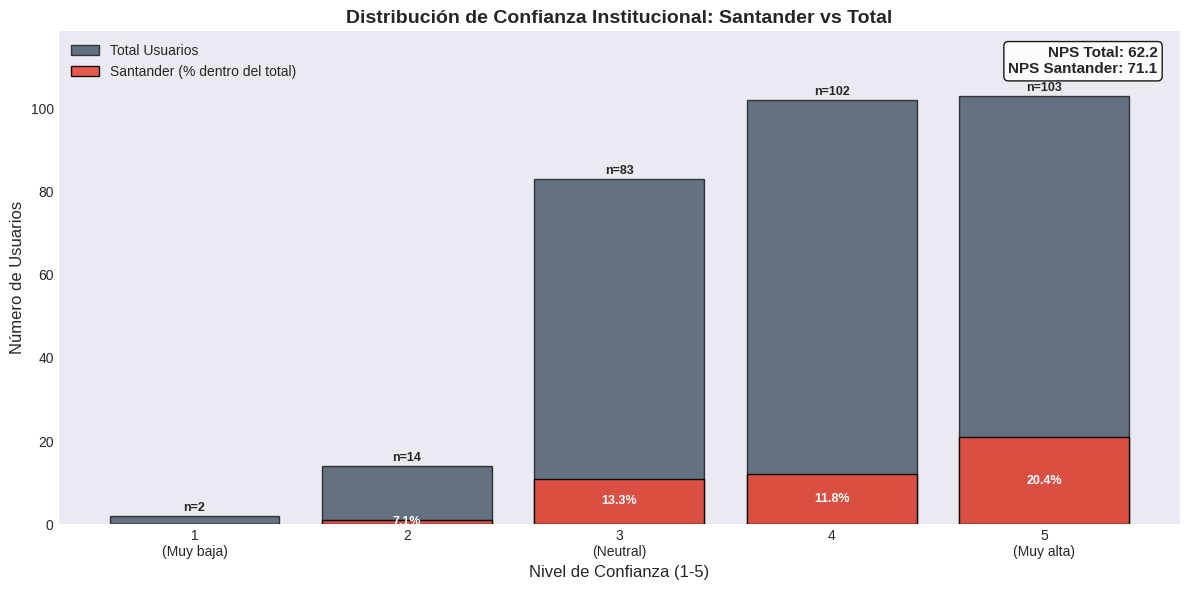

In [ ]:
# Santander vs Total de usuarios
# ============================================

# Preparar datos
niveles_confianza = [1, 2, 3, 4, 5]

# Contar usuarios por nivel
total_por_nivel = []
santander_por_nivel = []
porcentaje_santander_por_nivel = []

for nivel in niveles_confianza:
    count_total = len(total_confianza[total_confianza['Confianza_Institucion'] == nivel])
    count_santander = len(santander_confianza[santander_confianza['Confianza_Institucion'] == nivel])

    total_por_nivel.append(count_total)
    santander_por_nivel.append(count_santander)

    if count_total > 0:
        porcentaje_santander_por_nivel.append((count_santander / count_total) * 100)
    else:
        porcentaje_santander_por_nivel.append(0)

# Crear gráfica
fig, ax = plt.subplots(figsize=(12, 6))

# Barras principales (total usuarios)
barras = ax.bar(niveles_confianza, total_por_nivel,
                color='#2c3e50', alpha=0.7, edgecolor='black',
                label='Total Usuarios')

# Segmento rojo (porcentaje de Santander)
altura_santander = [total_por_nivel[i] * (porcentaje_santander_por_nivel[i] / 100)
                    for i in range(len(niveles_confianza))]

barras_santander = ax.bar(niveles_confianza, altura_santander,
                          color='#e74c3c', alpha=0.9, edgecolor='black',
                          label='Santander (% dentro del total)')

# Etiquetas
for i, (total, altura_roja, pct) in enumerate(zip(total_por_nivel, altura_santander, porcentaje_santander_por_nivel)):
    if total > 0:
        ax.text(i + 1, total + 0.5, f'n={total}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    if altura_roja > 0:
        ax.text(i + 1, altura_roja / 2, f'{pct:.1f}%', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')

# Configuración
ax.set_xlabel('Nivel de Confianza (1-5)', fontsize=12)
ax.set_ylabel('Número de Usuarios', fontsize=12)
ax.set_title('Distribución de Confianza Institucional: Santander vs Total', fontsize=14, fontweight='bold')
ax.set_xticks(niveles_confianza)
ax.set_xticklabels(['1\n(Muy baja)', '2', '3\n(Neutral)', '4', '5\n(Muy alta)'])

# Calcular NPS
def calcular_nps(df_grupo):
    if len(df_grupo) == 0:
        return 0
    promotores = len(df_grupo[df_grupo['Confianza_Institucion'] >= 4])
    detractores = len(df_grupo[df_grupo['Confianza_Institucion'] <= 2])
    return (promotores - detractores) / len(df_grupo) * 100

nps_total = calcular_nps(total_confianza)
nps_santander = calcular_nps(santander_confianza)

texto_nps = f'NPS Total: {nps_total:.1f}\nNPS Santander: {nps_santander:.1f}'
ax.text(0.98, 0.97, texto_nps, transform=ax.transAxes, ha='right', va='top',
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

ax.legend(loc='upper left')
ax.grid(False)
ax.set_ylim(0, max(total_por_nivel) * 1.15 if total_por_nivel else 10)

plt.tight_layout()
plt.show()

Gráfica 2: Importancia de Sucursales Físicas (Santander vs Fintechs)



 Distribución de tipos de usuario:
Tipo_Usuario
Solo Tradicional    218
Híbrido              74
Solo Fintech         12
Name: count, dtype: int64


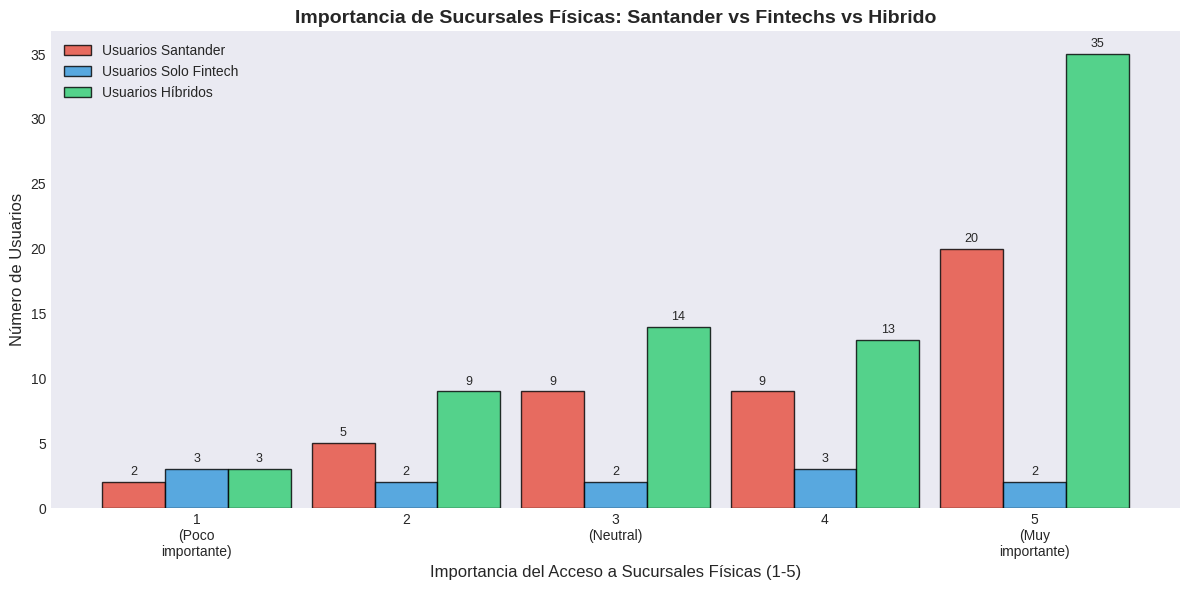


 COMPARATIVA: Importancia de Sucursales

 SANTANDER:
   • Promedio: 3.89/5
   • Usuarios que valoran mucho (4-5): 64.4%
   • Total usuarios: 45

 FINTECHS PURAS:
   • Promedio: 2.92/5
   • Usuarios que valoran mucho (4-5): 41.7%
   • Total usuarios: 12

 USUARIOS HIBRIDOS:
   • Promedio: 3.92/5
   • Usuarios que valoran mucho (4-5): 64.9%
   • Total usuarios: 74


In [ ]:
col_tipo = 'Tipo_Usuario'

print(f"\n Distribución de tipos de usuario:")
print(df[col_tipo].value_counts())

# Define fintechs_puras and usuarios_hibridos DataFrames
# santander_users is already defined in the previous cell
fintechs_puras = df[df[col_tipo] == 'Solo Fintech'].copy()
usuarios_hibridos = df[df[col_tipo] == 'Híbrido'].copy()

col_sucursales = 'Importancia_Acceso_Sucursales'

santander_users[col_sucursales] = pd.to_numeric(santander_users[col_sucursales], errors='coerce')
fintechs_puras[col_sucursales] = pd.to_numeric(fintechs_puras[col_sucursales], errors='coerce')
usuarios_hibridos[col_sucursales] = pd.to_numeric(usuarios_hibridos[col_sucursales], errors='coerce')

santander_sucursales = santander_users.dropna(subset=[col_sucursales])
fintechs_sucursales = fintechs_puras.dropna(subset=[col_sucursales])
usuarios_hibridos_sucursales = usuarios_hibridos.dropna(subset=[col_sucursales])

niveles_importancia = [1, 2, 3, 4, 5]
santander_counts = []
fintechs_counts = []
hibridos_counts = [] # Renamed to avoid overwriting the DataFrame

for nivel in niveles_importancia:
    santander_counts.append(len(santander_sucursales[santander_sucursales[col_sucursales] == nivel]))
    fintechs_counts.append(len(fintechs_sucursales[fintechs_sucursales[col_sucursales] == nivel]))
    hibridos_counts.append(len(usuarios_hibridos_sucursales[usuarios_hibridos_sucursales[col_sucursales] == nivel]))

# Gráfica

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(niveles_importancia))
bar_width = 0.30 # Adjusted width for individual bars

# Calculate positions for the three sets of bars
x_santander = x - bar_width
x_fintech = x
x_hibridos = x + bar_width

barras_santander = ax.bar(x_santander, santander_counts, bar_width,
                          label='Usuarios Santander', color='#e74c3c', alpha=0.8, edgecolor='black')
barras_fintech = ax.bar(x_fintech, fintechs_counts, bar_width,
                        label='Usuarios Solo Fintech', color='#3498db', alpha=0.8, edgecolor='black')
barras_hibridos = ax.bar(x_hibridos, hibridos_counts, bar_width,
                         label='Usuarios Híbridos', color='#2ecc71', alpha=0.8, edgecolor='black')

for barra in list(barras_santander) + list(barras_fintech) + list(barras_hibridos):
    height = barra.get_height()
    if height > 0:
        ax.text(barra.get_x() + barra.get_width()/2., height + 0.3, f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Importancia del Acceso a Sucursales Físicas (1-5)', fontsize=12)
ax.set_ylabel('Número de Usuarios', fontsize=12)
ax.set_title('Importancia de Sucursales Físicas: Santander vs Fintechs vs Hibrido', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['1\n(Poco\nimportante)', '2', '3\n(Neutral)', '4', '5\n(Muy\nimportante)'])
ax.legend(loc='upper left')
ax.grid(False)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(" COMPARATIVA: Importancia de Sucursales")
print("="*60)
if len(santander_sucursales) > 0:
    print(f"\n SANTANDER:")
    print(f"   • Promedio: {santander_sucursales[col_sucursales].mean():.2f}/5")
    print(f"   • Usuarios que valoran mucho (4-5): {(santander_sucursales[col_sucursales] >= 4).mean()*100:.1f}%")
    print(f"   • Total usuarios: {len(santander_sucursales)}")
if len(fintechs_sucursales) > 0:
    print(f"\n FINTECHS PURAS:")
    print(f"   • Promedio: {fintechs_sucursales[col_sucursales].mean():.2f}/5")
    print(f"   • Usuarios que valoran mucho (4-5): {(fintechs_sucursales[col_sucursales] >= 4).mean()*100:.1f}%")
    print(f"   • Total usuarios: {len(fintechs_sucursales)}")

if len(usuarios_hibridos_sucursales) > 0:
    print(f"\n USUARIOS HIBRIDOS:")
    print(f"   • Promedio: {usuarios_hibridos_sucursales[col_sucursales].mean():.2f}/5")
    print(f"   • Usuarios que valoran mucho (4-5): {(usuarios_hibridos_sucursales[col_sucursales] >= 4).mean()*100:.1f}%")
    print(f"   • Total usuarios: {len(usuarios_hibridos_sucursales)}")

Gráfica 3: Factores de Retención (Beneficios valorados)


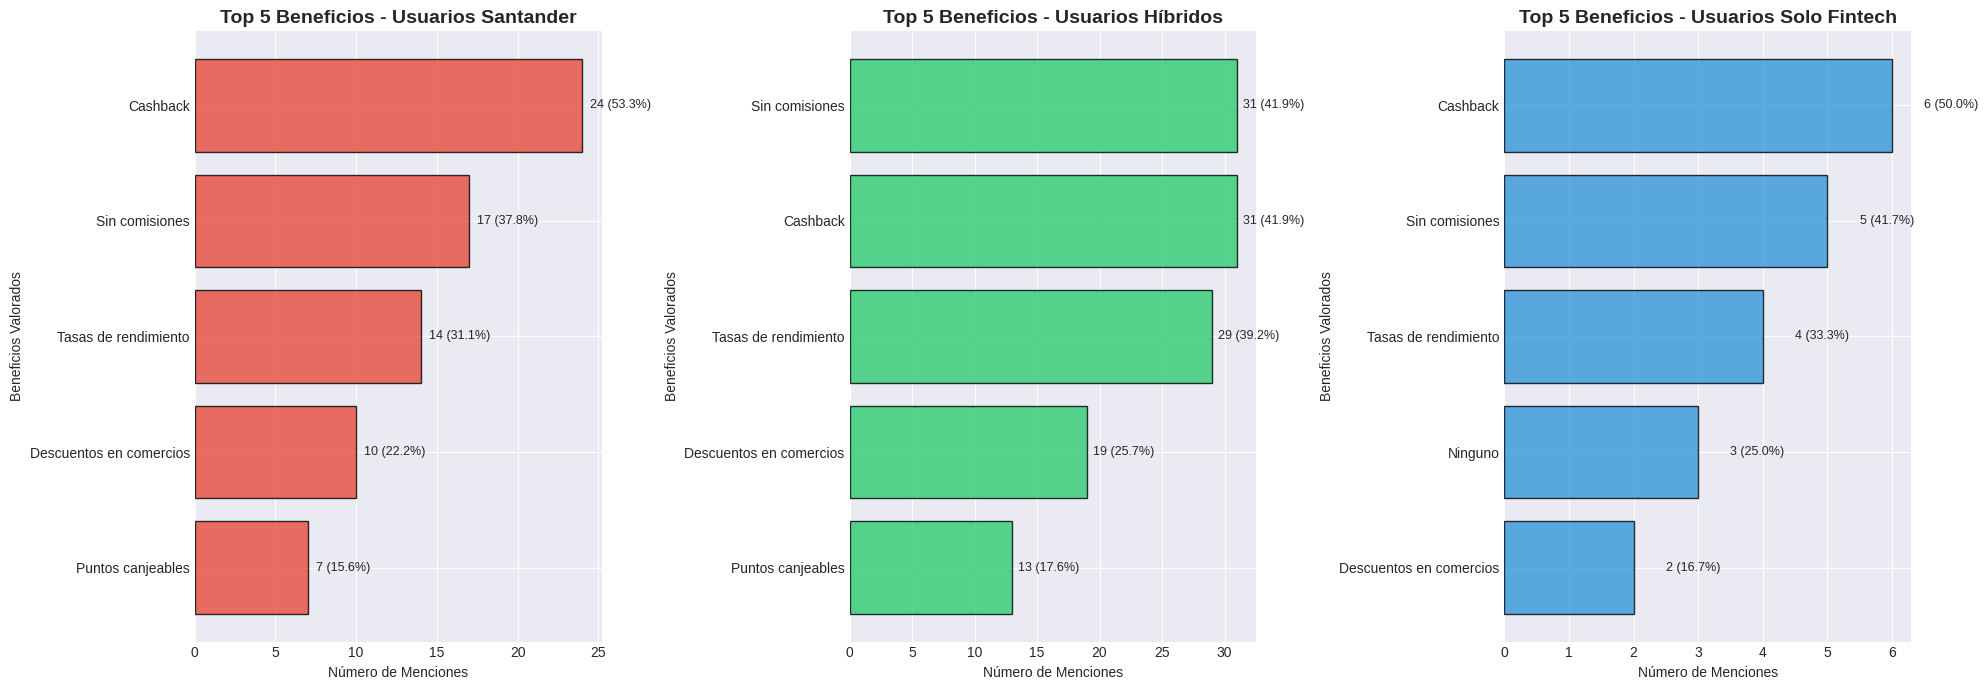


📊 TOP BENEFICIOS QUE RETIENEN A LOS USUARIOS:

   --- Santander ---
   • Cashback: 24 menciones (53.3% de usuarios Santander)
   • Sin comisiones: 17 menciones (37.8% de usuarios Santander)
   • Tasas de rendimiento: 14 menciones (31.1% de usuarios Santander)
   • Descuentos en comercios: 10 menciones (22.2% de usuarios Santander)
   • Puntos canjeables: 7 menciones (15.6% de usuarios Santander)

   --- Híbridos ---
   • Sin comisiones: 31 menciones (41.9% de usuarios Híbridos)
   • Cashback: 31 menciones (41.9% de usuarios Híbridos)
   • Tasas de rendimiento: 29 menciones (39.2% de usuarios Híbridos)
   • Descuentos en comercios: 19 menciones (25.7% de usuarios Híbridos)
   • Puntos canjeables: 13 menciones (17.6% de usuarios Híbridos)

   --- Solo Fintech ---
   • Cashback: 6 menciones (50.0% de usuarios Solo Fintech)
   • Sin comisiones: 5 menciones (41.7% de usuarios Solo Fintech)
   • Tasas de rendimiento: 4 menciones (33.3% de usuarios Solo Fintech)
   • Ninguno: 3 menciones (25

In [ ]:
# Beneficios más valorados por usuarios de Santander, Híbridos y Solo Fintech
# Beneficios_Valorados ya es lista (reconstruida por parse_lista al cargar el CSV)

beneficios_santander = []
beneficios_hibridos = []
beneficios_fintechs = []

# Populate benefits for Santander users
for lista in santander_users['Beneficios_Valorados']:
    if isinstance(lista, list):
        beneficios_santander.extend(lista)

# Populate benefits for Hybrid users
for lista in usuarios_hibridos['Beneficios_Valorados']:
    if isinstance(lista, list):
        beneficios_hibridos.extend(lista)

# Populate benefits for Solo Fintech users
for lista in fintechs_puras['Beneficios_Valorados']:
    if isinstance(lista, list):
        beneficios_fintechs.extend(lista)

# Calculate frequencies for each group
frecuencia_santander = Counter(beneficios_santander)
frecuencia_hibridos = Counter(beneficios_hibridos)
frecuencia_fintechs = Counter(beneficios_fintechs)

# Get top 5 benefits for each group
top_5_santander = frecuencia_santander.most_common(5)
top_5_hibridos = frecuencia_hibridos.most_common(5)
top_5_fintechs = frecuencia_fintechs.most_common(5)

# --- Plotting three separate bar charts for comparison ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=False)

# Plot for Santander Users
beneficios_nombres_santander = [item[0] for item in top_5_santander]
beneficios_counts_santander = [item[1] for item in top_5_santander]

axes[0].barh(beneficios_nombres_santander, beneficios_counts_santander, color='#e74c3c', alpha=0.8, edgecolor='black')
axes[0].set_title('Top 5 Beneficios - Usuarios Santander', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de Menciones')
axes[0].set_ylabel('Beneficios Valorados')
axes[0].invert_yaxis()
for i, (count, total_users_in_group) in enumerate(zip(beneficios_counts_santander, [len(santander_users)]*len(beneficios_counts_santander))):
    if total_users_in_group > 0:
        axes[0].text(count + 0.5, i, f'{count} ({count/total_users_in_group*100:.1f}%)', va='center', fontsize=9)

# Plot for Hybrid Users
beneficios_nombres_hibridos = [item[0] for item in top_5_hibridos]
beneficios_counts_hibridos = [item[1] for item in top_5_hibridos]

axes[1].barh(beneficios_nombres_hibridos, beneficios_counts_hibridos, color='#2ecc71', alpha=0.8, edgecolor='black')
axes[1].set_title('Top 5 Beneficios - Usuarios Híbridos', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Menciones')
axes[1].set_ylabel('Beneficios Valorados')
axes[1].invert_yaxis()
for i, (count, total_users_in_group) in enumerate(zip(beneficios_counts_hibridos, [len(usuarios_hibridos)]*len(beneficios_counts_hibridos))):
    if total_users_in_group > 0:
        axes[1].text(count + 0.5, i, f'{count} ({count/total_users_in_group*100:.1f}%)', va='center', fontsize=9)

# Plot for Solo Fintech Users
beneficios_nombres_fintechs = [item[0] for item in top_5_fintechs]
beneficios_counts_fintechs = [item[1] for item in top_5_fintechs]

axes[2].barh(beneficios_nombres_fintechs, beneficios_counts_fintechs, color='#3498db', alpha=0.8, edgecolor='black')
axes[2].set_title('Top 5 Beneficios - Usuarios Solo Fintech', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Número de Menciones')
axes[2].set_ylabel('Beneficios Valorados')
axes[2].invert_yaxis()
for i, (count, total_users_in_group) in enumerate(zip(beneficios_counts_fintechs, [len(fintechs_puras)]*len(beneficios_counts_fintechs))):
    if total_users_in_group > 0:
        axes[2].text(count + 0.5, i, f'{count} ({count/total_users_in_group*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 TOP BENEFICIOS QUE RETIENEN A LOS USUARIOS:")
print("\n   --- Santander ---")
for beneficio, count in top_5_santander:
    if len(santander_users) > 0:
        print(f"   • {beneficio}: {count} menciones ({count/len(santander_users)*100:.1f}% de usuarios Santander)")

print("\n   --- Híbridos ---")
for beneficio, count in top_5_hibridos:
    if len(usuarios_hibridos) > 0:
        print(f"   • {beneficio}: {count} menciones ({count/len(usuarios_hibridos)*100:.1f}% de usuarios Híbridos)")

print("\n   --- Solo Fintech ---")
for beneficio, count in top_5_fintechs:
    if len(fintechs_puras) > 0:
        print(f"   • {beneficio}: {count} menciones ({count/len(fintechs_puras)*100:.1f}% de usuarios Solo Fintech)")

In [ ]:
# ============================================
# HALLAZGOS CLAVE - RESUME
# ============================================

print("\n" + "="*60)
print(" HALLAZGOS CLAVE - ANÁLISIS SANTANDER")
print("="*60)

print(f"\n1. PRESENCIA EN EL MERCADO:")
print(f"   • Santander representa el {len(santander_users)/len(total_users)*100:.1f}% de los encuestados")

print(f"\n2. FORTALEZA EN CONFIANZA:")
print(f"   • NPS Santander: {nps_santander:.1f} vs NPS Total: {nps_total:.1f}")
if nps_santander > nps_total:
    print(f"   •  Santander SUPERA al promedio general en {nps_santander - nps_total:.1f} puntos NPS")

print(f"\n3. VENTAJA COMPETITIVA (Sucursales físicas):")
print(f"   • Los usuarios de Santander valoran más las sucursales ({importancia_promedio_santander:.2f})")
print(f"   • que los usuarios de fintechs puras ({importancia_promedio_total:.2f})")

print(f"\n4. EXPERIENCIA DIGITAL:")
print(f"   • Principales aspectos positivos de la app Santander:")
for aspecto, count in frecuencia_gustos.most_common(3):
    print(f"     - {aspecto}: {count} menciones")



 HALLAZGOS CLAVE - ANÁLISIS SANTANDER

1. PRESENCIA EN EL MERCADO:
   • Santander representa el 14.8% de los encuestados

2. FORTALEZA EN CONFIANZA:
   • NPS Santander: 71.1 vs NPS Total: 62.2
   •  Santander SUPERA al promedio general en 8.9 puntos NPS

3. VENTAJA COMPETITIVA (Sucursales físicas):
   • Los usuarios de Santander valoran más las sucursales (3.89)
   • que los usuarios de fintechs puras (4.03)

4. EXPERIENCIA DIGITAL:
   • Principales aspectos positivos de la app Santander:
     - Seguridad (biometría, alertas): 23 menciones
     - Diseño y facilidad de uso: 18 menciones
     - Funciones disponibles: 14 menciones


# Analisis de Sentimiento

### Feature Engineering

In [ ]:
# =====================================================
# ETAPA 2 — FEATURE ENGINEERING AVANZADO
# =====================================================
import ast
from collections import Counter

print("⚙️  FEATURE ENGINEERING")
print("=" * 60)

# ── helper: normalizar listas que vienen del CSV como string ──
def to_list(val):
    if isinstance(val, list): return val
    if not val or (isinstance(val, float) and np.isnan(val)): return []
    try:
        r = ast.literal_eval(str(val))
        return r if isinstance(r, list) else [r]
    except Exception:
      return [x.strip().strip("'\"") for x in str(val).strip("[]").split(",") if x.strip()]
LIST_COLS = ['Banco_Principal', 'Bancos_Lista', 'Fintechs_Utilizadas',
             'Preocupacion_Fintechs', 'Frustracion', 'Gusto',
             'Preocupacion_Seguridad', 'Razon_Consideraria_Cambiar',
             'Beneficios_Valorados']
for col in LIST_COLS:
    if col in df.columns:
        df[col] = df[col].apply(to_list)

# ── helper: texto de lista ──
def texto(val):
    lst = to_list(val) if not isinstance(val, list) else val
    return ' '.join(lst).lower()

# FEATURE 1 — SWITCHING RISK  (peso 30%)
# Razones explícitas de abandono
SWITCH_SCORES = {
    'mala experiencia':        4,
    'fraude':                  4,
    'cargo no autorizado':     4,
    'mejor app':               3,
    'comisiones más bajas':    3,
    'comisiones':              2,
    'mejores tasas':           3,
    'tasas':                   2,
    'cashback':                3,
    'recompensas':             2,
    'atención al cliente':     2,
    'rendimiento':             2,
}

def calc_switching_risk(val):
    t = texto(val)
    score = sum(v for k, v in SWITCH_SCORES.items() if k in t)
    return min(score, 10)

df['switching_risk'] = df['Razon_Consideraria_Cambiar'].apply(calc_switching_risk)
print(f"  switching_risk  (media={df['switching_risk'].mean():.2f})")

# FEATURE 2 — FINTECH RISK  (peso 20%)
# Familiaridad con competencia digital
FINTECH_SCORES = {
    'nu': 3, 'klar': 3, 'mercado pago': 2, 'stori': 2,
    'albo': 2, 'hey banco': 2, 'plata': 2, 'gbm': 2,
    'spin': 1, 'rappi card': 1, 'didi': 1, 'kueski': 1,
    'binance': 1, 'bitso': 1, 'wise': 1, 'paypal': 1,
}

def calc_fintech_risk(val):
    t = texto(val)
    score = sum(v for k, v in FINTECH_SCORES.items() if k in t)
    return min(score, 10)

df['fintech_risk'] = df['Fintechs_Utilizadas'].apply(calc_fintech_risk)
print(f"  fintech_risk    (media={df['fintech_risk'].mean():.2f})")

# FEATURE 3 — REWARDS RISK  (peso 15%)
# El usuario busca beneficios que Santander no lidera
REWARDS_SCORES = {
    'cashback':                    3,
    'recompensas o cashback':      3,
    'tasas de rendimiento':        3,
    'rendimiento':                 2,
    'puntos':                      2,
    'descuentos':                  2,
    'beneficios exclusivos':       1,
}

def calc_rewards_risk(val):
    t = texto(val)
    score = sum(v for k, v in REWARDS_SCORES.items() if k in t)
    return min(score, 10)

df['rewards_risk'] = df['Beneficios_Valorados'].apply(calc_rewards_risk)
print(f"  rewards_risk    (media={df['rewards_risk'].mean():.2f})")

# FEATURE 4 — APP RISK  (peso 10%)
# Fricción en la experiencia digital
APP_SCORES = {
    'errores o caídas':             3,
    'errores':                      2,
    'tiempos de carga':             2,
    'procesos con muchos pasos':    2,
    'soporte difícil':              2,
    'soporte':                      1,
    'login difícil':                1,
    'autenticación':                1,
}

def calc_app_risk(val):
    t = texto(val)
    score = sum(v for k, v in APP_SCORES.items() if k in t)
    return min(score, 10)

df['app_risk'] = df['Frustracion'].apply(calc_app_risk)
print(f"  app_risk        (media={df['app_risk'].mean():.2f})")

# FEATURE 5 — SECURITY RISK  (peso 10%)
# Daño a la confianza institucional
SECURITY_SCORES = {
    'fraude':                3,
    'cargo no autorizado':   3,
    'fuga de datos':         2,
    'uso indebido':          2,
    'phishing':              2,
    'app insegura':          1,
    'robo de identidad':     2,
}

def calc_security_risk(val):
    t = texto(val)
    score = sum(v for k, v in SECURITY_SCORES.items() if k in t)
    return min(score, 10)

df['security_risk'] = df['Preocupacion_Seguridad'].apply(calc_security_risk)
print(f"  security_risk   (media={df['security_risk'].mean():.2f})")

# FEATURE 6 — AGE RISK  (riesgo por generación)
AGE_MAP = {'18-25': 3, '26-40': 2, '41-55': 1, '56+': 0}

def calc_age_risk(val):
    for rango, score in AGE_MAP.items():
        if str(val).strip().startswith(rango.split('-')[0]):
            return score
    return 1

df['age_risk'] = df['Rango_Edad'].apply(calc_age_risk)
print(f"  age_risk        (media={df['age_risk'].mean():.2f})")

# FEATURE 7 — MULTI-APP RISK  (#_Apps_Tiene)
def calc_multiapp_risk(val):
    try:
        n = int(float(str(val)))
    except Exception:
        n = 1
    if n >= 4: return 3
    if n >= 2: return 2
    return 1

df['multiapp_risk'] = df['#_Apps_Tiene'].apply(calc_multiapp_risk)
print(f"  multiapp_risk   (media={df['multiapp_risk'].mean():.2f})")

# FEATURE 8 — PREFERENCE RISK  (Tipo_Usuario)
PREF_MAP = {'Solo Fintech': 4, 'Híbrido': 2, 'Solo Tradicional': 0}

def calc_pref_risk(val):
    return PREF_MAP.get(str(val).strip(), 1)

df['preference_risk'] = df['Tipo_Usuario'].apply(calc_pref_risk)
print(f"  preference_risk (media={df['preference_risk'].mean():.2f})")

# FEATURE 9 — UX FRUSTRATION INDEX  (variable de interacción)
# Cruza Dificultad_Transaccion × app_risk → riesgo exponencial
df['dificultad_num'] = pd.to_numeric(df['Dificultad_Transaccion'], errors='coerce').fillna(1)

def calc_ux_frustration(row):
    dif = row['dificultad_num']
    app = row['app_risk']
    # Usuarios con dif 4-5 Y errores técnicos tienen riesgo exponencial
    if dif >= 4 and app >= 3:
        return min((dif * app) / 3, 10)
    return min((dif + app) / 3, 10)

df['ux_frustration_idx'] = df.apply(calc_ux_frustration, axis=1).round(2)
print(f"  ux_frustration_idx (media={df['ux_frustration_idx'].mean():.2f})  [interacción]")

# FEATURE 10 — COMPETITIVENESS GAP  (variable de interacción)
# Valora cashback/tasas Y además tiene switching_risk alto
def calc_competitiveness_gap(row):
    rewards = row['rewards_risk']
    switching = row['switching_risk']
    t_switch = texto(row['Razon_Consideraria_Cambiar'])
    # Si además menciona mejores tasas o cashback en switching → gap crítico
    menciona_financiero = any(k in t_switch for k in ['mejores tasas', 'cashback', 'rendimiento'])
    base = (rewards + switching) / 2
    return min(base * 1.3, 10) if menciona_financiero else min(base, 10)

df['competitiveness_gap'] = df.apply(calc_competitiveness_gap, axis=1).round(2)
print(f"  competitiveness_gap (media={df['competitiveness_gap'].mean():.2f})  [interacción]")

print(f"\n  → {len([c for c in df.columns if c.endswith('_risk') or c.endswith('_idx') or c.endswith('_gap')])} features de riesgo generadas.")


⚙️  FEATURE ENGINEERING
  switching_risk  (media=5.93)
  fintech_risk    (media=1.75)
  rewards_risk    (media=3.34)
  app_risk        (media=2.31)
  security_risk   (media=2.09)
  age_risk        (media=1.80)
  multiapp_risk   (media=1.85)
  preference_risk (media=0.64)
  ux_frustration_idx (media=1.36)  [interacción]
  competitiveness_gap (media=5.30)  [interacción]

  → 10 features de riesgo generadas.


### Churn Risk Score

 CHURN RISK SCORE — SANTANDER

 Churn Score — estadísticas:
   • Media:   42.5
   • Mediana: 42.9
   • Mín/Máx: 0.0 / 100.0

 Distribución de Riesgo:
   🟡 Riesgo Medio: 147 usuarios (48.4%)
   🟢 Riesgo Bajo: 139 usuarios (45.7%)
   🔴 Riesgo Crítico: 18 usuarios (5.9%)

 NPS (proxy via Confianza_Institucion):
   • Promotores : 67.4%
   • Pasivos    : 27.3%
   • Detractores: 5.3%
    NPS estimado: 62.2

 Usuarios Santander: 45
   Churn Score promedio:      44.2
   Detractores (confianza≤2): 1 (2.2%)
   Riesgo Inversión crítico:  8 usuarios

 Distribución por segmento de vida (Santander):
                 mean  count
segmento_vida               
Consolidado      47.2     18
Retención (56+)  38.7     12
Volátil (18-25)  45.2     15

 Triggers más frecuentes (Santander):
trigger_accion
Activar beneficios de lealtad                                20
Sin acción inmediata                                         20
Comunicación proactiva de seguridad + revisión biométrica     3
Mejorar experien

/tmp/ipykernel_763/1978824214.py:178: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_763/1978824214.py:178: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_763/1978824214.py:178: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Liberati

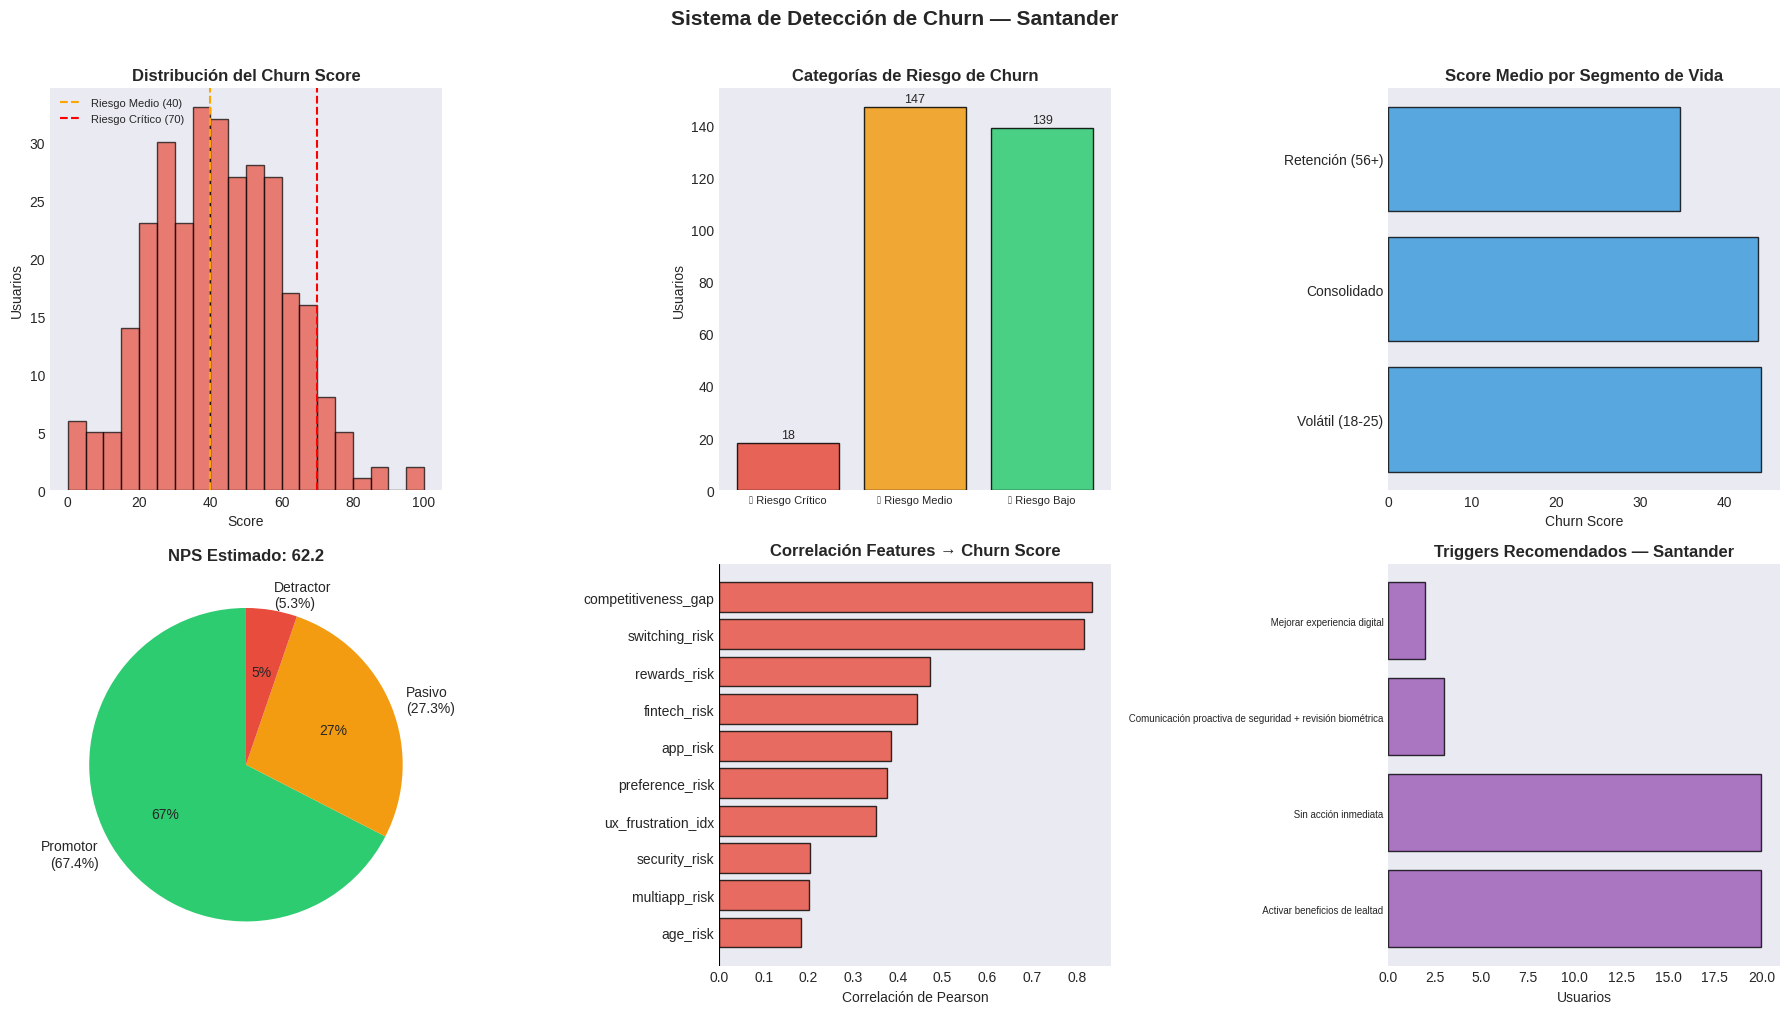


 MODELO PREDICTIVO — RANDOM FOREST

 Resultados (train=228 / test=76):
              precision    recall  f1-score   support

    Retenido       0.92      1.00      0.96        70
       Churn       0.00      0.00      0.00         6

    accuracy                           0.92        76
   macro avg       0.46      0.50      0.48        76
weighted avg       0.85      0.92      0.88        76



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


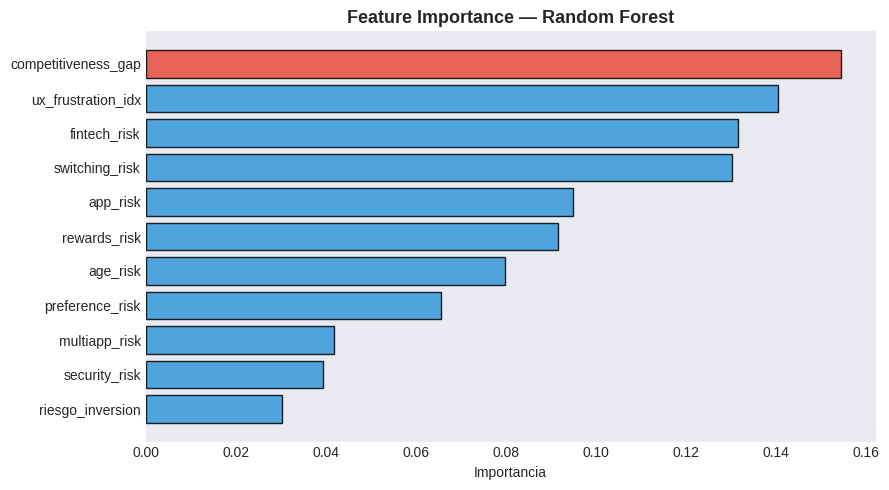


   Probabilidad ML guardada en 'churn_proba_ml'
     Media probabilidad churn (total):    0.139
     Usuarios Santander — proba media:    0.126

 TOP 15 USUARIOS SANTANDER — MAYOR RIESGO
     churn_score  churn_proba_ml        risk_level    segmento_vida                                              trigger_accion  riesgo_inversion
33         79.32           0.247  🔴 Riesgo Crítico      Consolidado   Comunicación proactiva de seguridad + revisión biométrica                 0
183        78.67           0.205  🔴 Riesgo Crítico      Consolidado   Comunicación proactiva de seguridad + revisión biométrica                 0
26         74.12           0.150  🔴 Riesgo Crítico      Consolidado   Comunicación proactiva de seguridad + revisión biométrica                 1
181        64.37           0.033    🟡 Riesgo Medio  Retención (56+)                               Activar beneficios de lealtad                 0
265        61.12           0.579    🟡 Riesgo Medio  Volátil (18-25)               

In [ ]:
# ETAPA 3 — CHURN RISK SCORE + NPS + RANDOM FOREST

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("=" * 60)
print(" CHURN RISK SCORE — SANTANDER")
print("=" * 60)

FEATURES_BASE = [
    'switching_risk',     # 30%
    'fintech_risk',       # 20%
    'rewards_risk',       # 15%
    'app_risk',           # 10%
    'security_risk',      # 10%
    'age_risk',           #  5%
    'multiapp_risk',      #  5%
    'preference_risk',    #  5%
]
PESOS = [0.30, 0.20, 0.15, 0.10, 0.10, 0.05, 0.05, 0.05]

# ─── Score base ponderado ────────────────────────────────────
df['churn_score_raw'] = sum(df[f] * w for f, w in zip(FEATURES_BASE, PESOS))

# ─── Multiplicador NPS (Confianza) ───────────────────────────
confianza_num = pd.to_numeric(df['Confianza_Institucion'], errors='coerce')
df['es_detractor'] = (confianza_num <= 2).astype(int)
df['churn_score_raw'] = df['churn_score_raw'] * (1 + df['es_detractor'] * 0.20)

# ─── Normalizar 0–100 ────────────────────────────────────────
mn, mx = df['churn_score_raw'].min(), df['churn_score_raw'].max()
df['churn_score'] = ((df['churn_score_raw'] - mn) / (mx - mn) * 100).round(2) if mx > mn else 0

# ─── Nivel de riesgo ─────────────────────────────────────────
def risk_level(s):
    if s >= 70: return '🔴 Riesgo Crítico'
    if s >= 40: return '🟡 Riesgo Medio'
    return '🟢 Riesgo Bajo'

df['risk_level'] = df['churn_score'].apply(risk_level)

# ─── Segmento de vida ────────────────────────────────────────
def segmento_vida(row):
    edad = str(row['Rango_Edad'])
    if '18' in edad or '25' in edad:
        return 'Volátil (18-25)'
    elif '56' in edad or '60' in edad:
        return 'Retención (56+)'
    return 'Consolidado'

df['segmento_vida'] = df.apply(segmento_vida, axis=1)

# ─── Trigger de acción ───────────────────────────────────────
def trigger_accion(row):
    score = row['churn_score']
    sec   = row.get('security_risk', 0)
    rew   = row.get('rewards_risk', 0)
    if score >= 70:
        if sec >= 3: return ' Comunicación proactiva de seguridad + revisión biométrica'
        if rew >= 3: return ' Oferta personalizada: cashback / tasa de rendimiento'
        return        '📞 Contacto preventivo + revisión de comisiones'
    if score >= 40:
        if rew >= 2: return ' Activar beneficios de lealtad'
        return        ' Mejorar experiencia digital'
    return            ' Sin acción inmediata'

df['trigger_accion'] = df.apply(trigger_accion, axis=1)

# ─── Riesgo inversión ────────────────────────────────────────
def riesgo_inversion(row):
    t_ben = texto(row['Beneficios_Valorados'])
    t_sw  = texto(row['Razon_Consideraria_Cambiar'])
    busca_rendimiento = any(k in t_ben for k in ['rendimiento', 'tasas', 'interés'])
    menciona_tasas    = any(k in t_sw  for k in ['mejores tasas', 'rendimiento'])
    return int(busca_rendimiento and menciona_tasas)

df['riesgo_inversion'] = df.apply(riesgo_inversion, axis=1)

# ─── Helper: siempre obtiene san actualizado desde df ────────
def get_santander(dataframe):
    return dataframe[dataframe['Banco_Principal'].apply(
        lambda x: 'Santander' in x if isinstance(x, list) else x == 'Santander'
    )].copy()

# DISTRIBUCIÓN GENERAL
print(f"\n Churn Score — estadísticas:")
print(f"   • Media:   {df['churn_score'].mean():.1f}")
print(f"   • Mediana: {df['churn_score'].median():.1f}")
print(f"   • Mín/Máx: {df['churn_score'].min():.1f} / {df['churn_score'].max():.1f}")

print(f"\n Distribución de Riesgo:")
for lvl, cnt in df['risk_level'].value_counts().items():
    print(f"   {lvl}: {cnt} usuarios ({cnt/len(df)*100:.1f}%)")

# NPS — PROMOTORES, PASIVOS, DETRACTORES
confianza = pd.to_numeric(df['Confianza_Institucion'], errors='coerce').dropna()

def nps_cat(v):
    if v >= 4: return 'Promotor'
    if v == 3: return 'Pasivo'
    return 'Detractor'

nps_series = confianza.apply(nps_cat)
pct        = nps_series.value_counts(normalize=True) * 100
nps_score  = pct.get('Promotor', 0) - pct.get('Detractor', 0)

print(f"\n NPS (proxy via Confianza_Institucion):")
print(f"   • Promotores : {pct.get('Promotor',0):.1f}%")
print(f"   • Pasivos    : {pct.get('Pasivo',0):.1f}%")
print(f"   • Detractores: {pct.get('Detractor',0):.1f}%")
print(f"    NPS estimado: {nps_score:.1f}")

# ANÁLISIS SANTANDER
san = get_santander(df)

print(f"\n Usuarios Santander: {len(san)}")
print(f"   Churn Score promedio:      {san['churn_score'].mean():.1f}")
print(f"   Detractores (confianza≤2): {san['es_detractor'].sum()} ({san['es_detractor'].mean()*100:.1f}%)")
print(f"   Riesgo Inversión crítico:  {san['riesgo_inversion'].sum()} usuarios")

print(f"\n Distribución por segmento de vida (Santander):")
print(san.groupby('segmento_vida')['churn_score'].agg(['mean','count']).round(1))

print(f"\n Triggers más frecuentes (Santander):")
print(san['trigger_accion'].value_counts())

# VISUALIZACIONES
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].hist(df['churn_score'], bins=20, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0,0].axvline(40, color='orange', linestyle='--', linewidth=1.5, label='Riesgo Medio (40)')
axes[0,0].axvline(70, color='red',    linestyle='--', linewidth=1.5, label='Riesgo Crítico (70)')
axes[0,0].set_title('Distribución del Churn Score', fontweight='bold')
axes[0,0].set_xlabel('Score'); axes[0,0].set_ylabel('Usuarios')
axes[0,0].legend(fontsize=8); axes[0,0].grid(False)

riesgo_ord = ['🔴 Riesgo Crítico', '🟡 Riesgo Medio', '🟢 Riesgo Bajo']
colores_r  = ['#e74c3c', '#f39c12', '#2ecc71']
conteos_r  = [df['risk_level'].value_counts().get(r, 0) for r in riesgo_ord]
bars = axes[0,1].bar(riesgo_ord, conteos_r, color=colores_r, alpha=0.85, edgecolor='black')
axes[0,1].set_title('Categorías de Riesgo de Churn', fontweight='bold')
axes[0,1].set_ylabel('Usuarios')
for b, c in zip(bars, conteos_r):
    axes[0,1].text(b.get_x()+b.get_width()/2, c+1, str(c), ha='center', va='bottom', fontsize=9)
axes[0,1].grid(False)
axes[0,1].tick_params(axis='x', labelsize=8)

seg_data = df.groupby('segmento_vida')['churn_score'].mean().sort_values(ascending=False)
axes[0,2].barh(seg_data.index, seg_data.values, color='#3498db', alpha=0.8, edgecolor='black')
axes[0,2].set_title('Score Medio por Segmento de Vida', fontweight='bold')
axes[0,2].set_xlabel('Churn Score'); axes[0,2].grid(False)

nps_counts = nps_series.value_counts()
nps_col    = {'Promotor': '#2ecc71', 'Pasivo': '#f39c12', 'Detractor': '#e74c3c'}
axes[1,0].pie(
    [nps_counts.get(k, 0) for k in nps_col],
    labels=[f"{k}\n({pct.get(k,0):.1f}%)" for k in nps_col],
    colors=list(nps_col.values()), autopct='%1.0f%%', startangle=90
)
axes[1,0].set_title(f'NPS Estimado: {nps_score:.1f}', fontweight='bold')

feats_plot = FEATURES_BASE + ['ux_frustration_idx', 'competitiveness_gap']
corr_vals  = df[feats_plot + ['churn_score']].corr()['churn_score'].drop('churn_score').sort_values()
colors_c   = ['#e74c3c' if v > 0 else '#3498db' for v in corr_vals]
axes[1,1].barh(corr_vals.index, corr_vals.values, color=colors_c, alpha=0.8, edgecolor='black')
axes[1,1].axvline(0, color='black', linewidth=0.8)
axes[1,1].set_title('Correlación Features → Churn Score', fontweight='bold')
axes[1,1].set_xlabel('Correlación de Pearson'); axes[1,1].grid(False)

tc = san['trigger_accion'].value_counts().head(5)
axes[1,2].barh(tc.index, tc.values, color='#9b59b6', alpha=0.8, edgecolor='black')
axes[1,2].set_title('Triggers Recomendados — Santander', fontweight='bold')
axes[1,2].set_xlabel('Usuarios'); axes[1,2].grid(False)
axes[1,2].tick_params(axis='y', labelsize=7)

plt.suptitle('Sistema de Detección de Churn — Santander', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# MODELO RANDOM FOREST (ML)
print("\n" + "=" * 60)
print(" MODELO PREDICTIVO — RANDOM FOREST")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

if 'Preferencia_Fintech_vs_Tradicional' in df.columns:
    df['target_churn'] = (df['Preferencia_Fintech_vs_Tradicional'].str.strip() == 'Si').astype(int)
else:
    df['target_churn'] = (df['churn_score'] >= 70).astype(int)

ML_FEATURES = FEATURES_BASE + ['ux_frustration_idx', 'competitiveness_gap', 'riesgo_inversion']

df_ml = df[ML_FEATURES + ['target_churn']].dropna()
X = df_ml[ML_FEATURES]
y = df_ml['target_churn']

rf_entrenado = False  # flag — controla si la columna churn_proba_ml existe

if len(y.unique()) > 1 and len(X) > 30:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=6, random_state=42, class_weight='balanced'
    )
    rf.fit(X_train, y_train)

    print(f"\n Resultados (train={len(X_train)} / test={len(X_test)}):")
    print(classification_report(y_test, rf.predict(X_test), target_names=['Retenido', 'Churn']))

    fi = pd.Series(rf.feature_importances_, index=ML_FEATURES).sort_values(ascending=True)
    fig2, ax2 = plt.subplots(figsize=(9, 5))
    colors_fi = ['#e74c3c' if fi[f] == fi.max() else '#3498db' for f in fi.index]
    ax2.barh(fi.index, fi.values, color=colors_fi, alpha=0.85, edgecolor='black')
    ax2.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Importancia'); ax2.grid(False)
    plt.tight_layout(); plt.show()

    # Guardar probabilidades en df ANTES de refrescar san
    df['churn_proba_ml'] = np.nan
    df_ml_full = df[ML_FEATURES].dropna()
    df.loc[df_ml_full.index, 'churn_proba_ml'] = rf.predict_proba(df_ml_full)[:, 1].round(3)
    rf_entrenado = True

    # Refrescar san DESPUÉS de que churn_proba_ml ya existe en df
    san = get_santander(df)

    print(f"\n   Probabilidad ML guardada en 'churn_proba_ml'")
    print(f"     Media probabilidad churn (total):    {df['churn_proba_ml'].mean():.3f}")
    print(f"     Usuarios Santander — proba media:    {san['churn_proba_ml'].mean():.3f}")
else:
    print("    Muestra insuficiente para entrenar RF. Se usa solo el score ponderado.")
    san = get_santander(df)  # refrescar de todas formas para consistencia

# TABLA RESUMEN SANTANDER
print("\n" + "=" * 60)
print(" TOP 15 USUARIOS SANTANDER — MAYOR RIESGO")
print("=" * 60)

cols_show = ['churn_score', 'risk_level', 'segmento_vida', 'trigger_accion', 'riesgo_inversion']

# Incluir columna ML solo si el RF corrió Y san tiene valores no nulos
if rf_entrenado and 'churn_proba_ml' in san.columns and san['churn_proba_ml'].notna().any():
    cols_show.insert(1, 'churn_proba_ml')

print(san.sort_values('churn_score', ascending=False)[cols_show].head(15).to_string())

print("\n" + "=" * 60)
print(" SISTEMA DE CHURN COMPLETO")
print("=" * 60)



#Regresion Logistica Clasificatoria

 REGRESIÓN LOGÍSTICA — CLASIFICACIÓN DE RIESGO

 Distribución del target:
   Riesgo Bajo: 139 usuarios (45.7%)
   Riesgo Medio: 147 usuarios (48.4%)
   Riesgo Alto: 18 usuarios (5.9%)

 Reporte de clasificación (test=76 usuarios):
              precision    recall  f1-score   support

 Riesgo Bajo       0.97      1.00      0.99        35
Riesgo Medio       0.97      0.84      0.90        37
 Riesgo Alto       0.38      0.75      0.50         4

    accuracy                           0.91        76
   macro avg       0.77      0.86      0.79        76
weighted avg       0.94      0.91      0.92        76



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

 Accuracy promedio (5-fold CV): 0.934 ± 0.028

 Coeficientes por clase (más alto = mayor influencia):
              switching_risk  fintech_risk  rewards_risk  app_risk  security_risk  age_risk  multiapp_risk  preference_risk  ux_frustration_idx  competitiveness_gap  riesgo_inversion
Riesgo Bajo           -2.418        -1.416        -1.270    -1.231         -1.308    -0.125          0.013           -0.554              -0.505               -1.553             0.221
Riesgo Medio           0.169         0.213        -0.385    -0.327         -0.016    -0.060          0.064           -0.015               0.256                0.401            -0.240
Riesgo Alto            2.249         1.204         1.655     1.558          1.324     0.184         -0.078            0.569               0.249                1.152             0.019


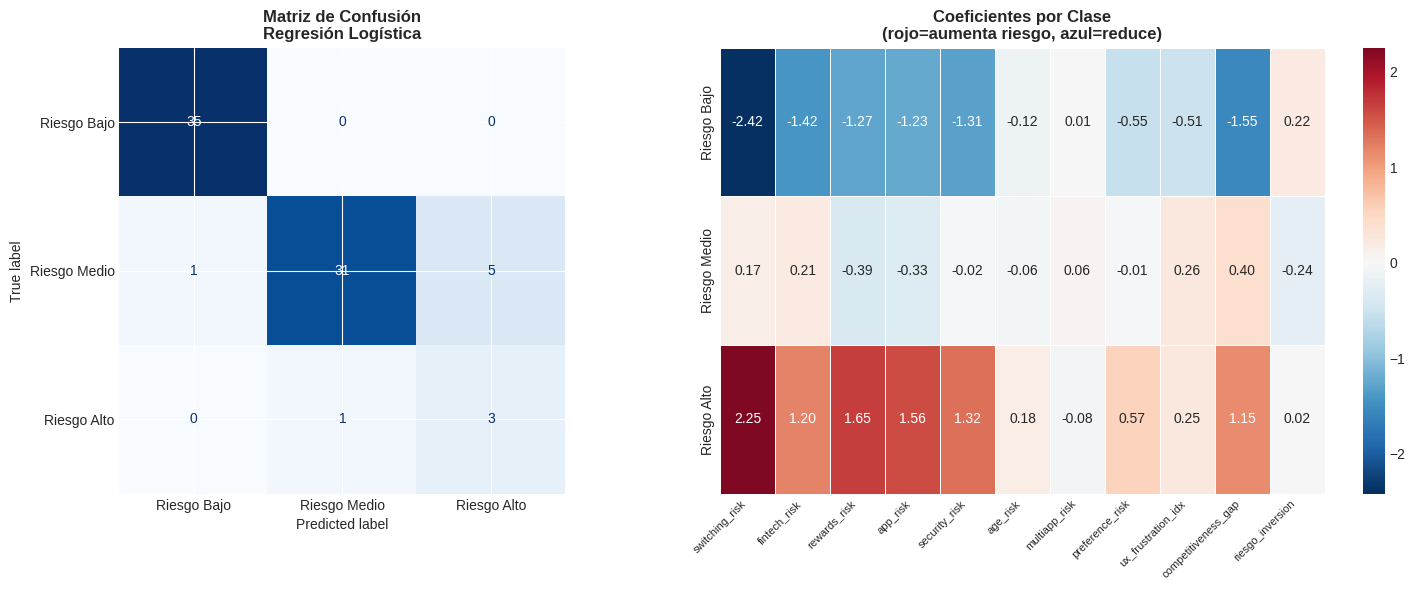


 Clasificación Logística — Usuarios Santander:
clase_lr_label
Riesgo Bajo     21
Riesgo Medio    20
Riesgo Alto      4
Name: count, dtype: int64

   Probabilidad promedio Riesgo Alto: 0.102

 Top 10 Santander — Mayor probabilidad de Riesgo Alto:
     churn_score clase_lr_label  proba_alto_lr                                              trigger_accion
33         79.32    Riesgo Alto       0.998878   Comunicación proactiva de seguridad + revisión biométrica
183        78.67    Riesgo Alto       0.954938   Comunicación proactiva de seguridad + revisión biométrica
26         74.12    Riesgo Alto       0.849560   Comunicación proactiva de seguridad + revisión biométrica
71         60.47    Riesgo Alto       0.667509                               Activar beneficios de lealtad
172        50.72   Riesgo Medio       0.429573                               Activar beneficios de lealtad
181        64.37   Riesgo Medio       0.171243                               Activar beneficios de lealtad
265 

In [ ]:
# MODELO — REGRESIÓN LOGÍSTICA MULTICLASE
# Clasifica: Riesgo Bajo / Medio / Alto

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("=" * 60)
print(" REGRESIÓN LOGÍSTICA — CLASIFICACIÓN DE RIESGO")
print("=" * 60)

# ── Target: 3 clases basadas en churn_score ──────────────────
def score_a_clase(s):
    if s >= 70: return 2   # Alto
    if s >= 40: return 1   # Medio
    return 0               # Bajo

LABEL_MAP = {0: 'Riesgo Bajo', 1: 'Riesgo Medio', 2: 'Riesgo Alto'}

df['target_3clases'] = df['churn_score'].apply(score_a_clase)

print("\n Distribución del target:")
for k, label in LABEL_MAP.items():
    n = (df['target_3clases'] == k).sum()
    print(f"   {label}: {n} usuarios ({n/len(df)*100:.1f}%)")

# ── Features (las mismas del sistema de churn) ───────────────
ML_FEATURES = [
    'switching_risk', 'fintech_risk', 'rewards_risk',
    'app_risk', 'security_risk', 'age_risk',
    'multiapp_risk', 'preference_risk',
    'ux_frustration_idx', 'competitiveness_gap', 'riesgo_inversion'
]

df_ml = df[ML_FEATURES + ['target_3clases']].dropna()
X = df_ml[ML_FEATURES].values
y = df_ml['target_3clases'].values

# ── Escalar (necesario para regresión logística) ──────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Split y entrenamiento ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

lr = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr.fit(X_train, y_train)

# ── Métricas ──────────────────────────────────────────────────
y_pred = lr.predict(X_test)
target_names = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

print(f"\n Reporte de clasificación (test={len(y_test)} usuarios):")
print(classification_report(y_test, y_pred, target_names=target_names))

cv_scores = cross_val_score(lr, X_scaled, y, cv=5, scoring='accuracy')
print(f" Accuracy promedio (5-fold CV): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# ── Coeficientes — qué variable impulsa cada clase ────────────
coef_df = pd.DataFrame(
    lr.coef_,
    index=[LABEL_MAP[i] for i in lr.classes_],
    columns=ML_FEATURES
)

print("\n Coeficientes por clase (más alto = mayor influencia):")
print(coef_df.round(3).to_string())

# ── Visualizaciones ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de confusión
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=target_names,
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Matriz de Confusión\nRegresión Logística', fontweight='bold')

# Coeficientes por clase (heatmap)
import seaborn as sns
sns.heatmap(
    coef_df, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, ax=axes[1], linewidths=0.5
)
axes[1].set_title('Coeficientes por Clase\n(rojo=aumenta riesgo, azul=reduce)', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

# ── Guardar predicciones en el dataframe ─────────────────────
df['clase_lr']      = np.nan
df['proba_alto_lr'] = np.nan

X_full = scaler.transform(df[ML_FEATURES].dropna().values)
idx_full = df[ML_FEATURES].dropna().index

df.loc[idx_full, 'clase_lr']      = lr.predict(X_full)
df.loc[idx_full, 'proba_alto_lr'] = lr.predict_proba(X_full)[:, 2]  # prob clase Alto

df['clase_lr_label'] = df['clase_lr'].map(LABEL_MAP)

# ── Resumen Santander ─────────────────────────────────────────
san = df[df['Banco_Principal'].apply(
    lambda x: 'Santander' in x if isinstance(x, list) else x == 'Santander'
)].copy()

print("\n Clasificación Logística — Usuarios Santander:")
print(san['clase_lr_label'].value_counts())
print(f"\n   Probabilidad promedio Riesgo Alto: {san['proba_alto_lr'].mean():.3f}")

print("\n Top 10 Santander — Mayor probabilidad de Riesgo Alto:")
cols_lr = ['churn_score', 'clase_lr_label', 'proba_alto_lr', 'trigger_accion']
print(san.sort_values('proba_alto_lr', ascending=False)[cols_lr].head(10).to_string())